In [ ]:
%matplotlib inline

from pathlib import Path

import chaosmagpy as cp
import cmcrameri.cm as cmc
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import scipy.io as spio
from scipy import stats
import seaborn as sns
import cartopy.crs as ccrs
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from chaosmagpy.model_utils import design_gauss

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
})


In [24]:
ASSIGNMENT_DIR = Path().resolve().parent
EXPORT_DIR = ASSIGNMENT_DIR / "export_L2_jk_style"
EXPORT_DIR.mkdir(exist_ok=True)

SAVEFIG_ARGS = {
    "dpi": 600,
    "bbox_inches": "tight",
}

In [25]:
# Constants
a = 6371.2
c = 3480.0
ps_r = c
limit = [-1.5, 1.5]   # JK uses [-1.5, 1.5] in his notebook

In [26]:
# Load data
data = spio.loadmat("SW_B_14_28_Sept14_selected.mat")
d = data["Br"].reshape(-1,)
theta = data["theta"].reshape(-1,)
phi = data["lambda"].reshape(-1,)
r = data["r"].reshape(-1,)

In [27]:
def format_number(x: float, sigfigs: int = 3) -> str:
    """
    Small replacement for JK's utils_jk.format_number.
    Returns a compact scientific notation string for LaTeX titles.
    """
    s = f"{x:.{sigfigs-1}e}"
    mantissa, exponent = s.split("e")
    return rf"{float(mantissa):.{sigfigs-1}f}\times 10^{{{int(exponent)}}}"

In [28]:
def plot_global(lon, lat, data, point_size, title="", cbar_label="", cmap=None,
                limit=None, half_page=False, ignore_cbar=False):
    """
    Self-contained plotting helper made to resemble JK's utils_given.plot_global.
    """
    if limit is None:
        vmax = np.max(np.abs(data))
    else:
        vmax = np.max(np.abs(np.asarray(limit)))

    figsize = (4.6, 3.2) if half_page else (9.0, 5.2)
    fig = plt.figure(figsize=figsize)

    gs = fig.add_gridspec(
        2, 3,
        width_ratios=[1, 1, 1],
        height_ratios=[0.35, 0.65],
    )

    axes = [
        fig.add_subplot(gs[0, 0], projection=ccrs.NearsidePerspective(central_latitude=90.0)),
        fig.add_subplot(gs[0, 2], projection=ccrs.NearsidePerspective(central_latitude=-90.0)),
        fig.add_subplot(gs[1, :], projection=ccrs.Mollweide()),
    ]

    pc = None
    for ax in axes:
        pc = ax.scatter(
            lon, lat, c=data, s=point_size, cmap=cmap, vmin=-vmax, vmax=vmax,
            transform=ccrs.PlateCarree()
        )
        ax.gridlines(
            linewidth=0.5,
            ylocs=np.linspace(-90, 90, num=7),
            xlocs=np.linspace(-180, 180, num=13),
            color="grey",
            alpha=0.6,
            linestyle="-",
        )
        ax.coastlines(linewidth=0.5)

    if (not ignore_cbar) and (pc is not None):
        cax = inset_axes(
            axes[-1], width="55%", height="10%", loc="upper center",
            borderpad=-9 if not half_page else -8.3
        )
        clb = plt.colorbar(pc, cax=cax, extend="both", orientation="horizontal")
        clb.set_label(cbar_label, fontsize=9)
        clb.ax.tick_params(labelsize=8)

    fig.suptitle(title, fontsize=10)
    fig.subplots_adjust(
        top=0.90 if half_page else 0.95,
        bottom=0.05 if half_page else 0.02,
        left=0.02,
        right=0.98,
        hspace=0.02,
        wspace=0.02,
    )
    return fig

In [29]:
def plot_power_spectrum(model, N, radius):
    fig, ax = plt.subplots(figsize=(4, 3))
    ps = cp.model_utils.power_spectrum(model, radius=radius)
    n = np.arange(1, N + 1)
    ax.semilogy(n, ps)
    ax.set_xlabel("Degree, $n$", fontsize=9)
    ax.set_ylabel(r"Power [nT$^2$]", fontsize=9)
    ax.set_title("Power Spectrum at CMB", fontsize=10)
    ax.set_xticks(np.arange(1, N + 1, 2))
    ax.tick_params(labelsize=8)
    ax.grid()
    fig.tight_layout()
    return fig

In [30]:
def l_curve_corner_chord_distance(rho, eta, reg_param):
    """
    Self-contained replacement for JK's imported corner finder.
    Uses log-log chord distance.
    """
    rho = np.asarray(rho, dtype=float)
    eta = np.asarray(eta, dtype=float)
    reg_param = np.asarray(reg_param, dtype=float)

    x = np.log10(rho)
    y = np.log10(eta)

    p1 = np.array([x[0], y[0]])
    p2 = np.array([x[-1], y[-1]])
    line = p2 - p1
    line_norm = np.linalg.norm(line)

    if line_norm == 0:
        idx = len(reg_param) // 2
        return reg_param[idx], idx, np.zeros_like(reg_param)

    distances = []
    for xi, yi in zip(x, y):
        p = np.array([xi, yi])
        dist = np.abs(np.cross(line, p - p1)) / line_norm
        distances.append(dist)

    distances = np.asarray(distances)
    idx = int(np.argmax(distances))
    return reg_param[idx], idx, distances

In [31]:
def solve_L2(G, H, d, alpha):
    GTG = G.T @ G
    HTH = H.T @ H
    return np.linalg.solve(GTG + (alpha**2) * HTH, G.T @ d)

def get_residual(G, m, d):
    return G @ m - d

def mad_scale(x):
    x = np.asarray(x)
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    return max((1 / 0.675) * mad, 1e-14)

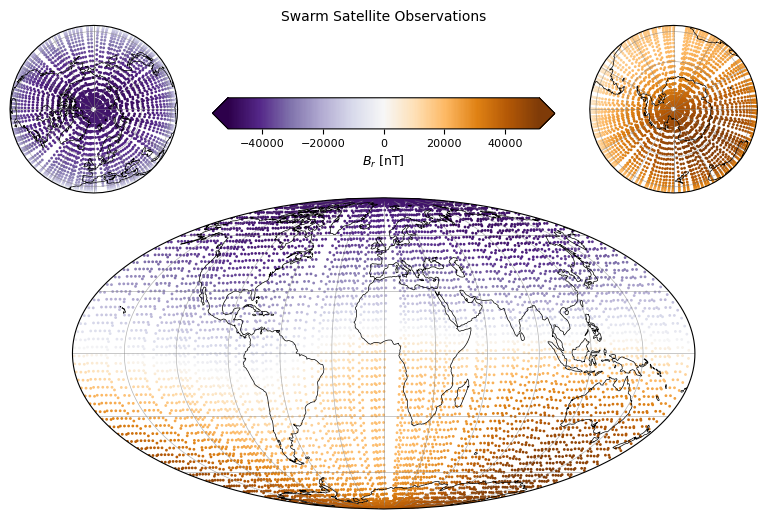

In [32]:
# Plot raw observations
point_size = 1
fig_data = plot_global(
    phi, 90 - theta, d, point_size,
    title="Swarm Satellite Observations",
    cbar_label="$B_r$ [nT]",
    cmap=plt.cm.PuOr_r,
    half_page=False,
)
fig_data.savefig(EXPORT_DIR / "data_swarm.png", **SAVEFIG_ARGS)
plt.show()

In [ ]:
N = 20
Gr, _, _ = design_gauss(r, theta, phi, N)

phi_cmb, theta_cmb = np.meshgrid(
    np.linspace(-177.5, 177.5, num=70),
    np.linspace(2.5, 177.5, num=36),
)
phi_cmb = phi_cmb.reshape(-1,)
theta_cmb = theta_cmb.reshape(-1,)
r_cmb = c * np.ones(theta_cmb.shape)

H_Br_cmb, _, _ = design_gauss(r_cmb, theta_cmb, phi_cmb, N)
R = H_Br_cmb.T @ H_Br_cmb

phi_plot, theta_plot = np.meshgrid(
    np.linspace(-179.0, 180.0, num=360),
    np.linspace(1.0, 179.0, num=180),
)
phi_plot = phi_plot.reshape(-1,)
theta_plot = theta_plot.reshape(-1,)
r_plot = c * np.ones(theta_plot.shape)

Gr_plot, _, _ = design_gauss(r_plot, theta_plot, phi_plot, N)

L2 regularization section

In [ ]:
alphas = np.geomspace(1e-5, 1e-3, num=50)
L_curve_data = []

for alpha in alphas:
    m_L2 = solve_L2(Gr, H_Br_cmb, d, alpha)
    r_L2 = get_residual(Gr, m_L2, d)
    L_curve_data.append(
        {
            "alpha": alpha,
            "residual_norm": np.linalg.norm(r_L2) ** 2,
            "model_norm": np.linalg.norm(H_Br_cmb @ m_L2) ** 2,
        }
    )

df = pl.DataFrame(L_curve_data)
res_norm = df["residual_norm"].to_numpy()
mod_norm = df["model_norm"].to_numpy()
alphas = df["alpha"].to_numpy()

alpha_corner, idx_corner, kappa = l_curve_corner_chord_distance(
    res_norm,
    mod_norm,
    alphas,
)

/var/folders/d6/cgrlj7vs36nccd69q23h6h3h0000gn/T/ipykernel_61875/60354019.py:25: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  dist = np.abs(np.cross(line, p - p1)) / line_norm


(L2 L-curve)

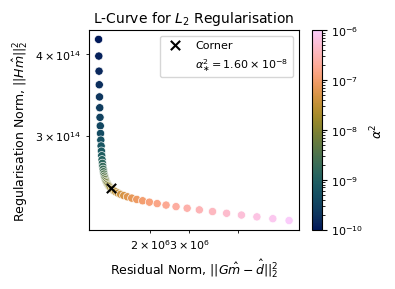

alpha_corner = 1.2649e-04
alpha_corner**2 = 1.5999e-08


In [53]:
# Use alpha^2 for colorbar
alpha_sq = alphas**2

fig, ax = plt.subplots(figsize=(4, 3))
cmap = cmc.batlow
norm = mpl.colors.LogNorm(vmin=alpha_sq.min(), vmax=alpha_sq.max())
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)

alpha_sq_corner = alpha_corner**2
mantissa, exponent = f"{alpha_sq_corner:.2e}".split("e")
alpha_label = rf"$\alpha_{{\ast}}^2 = {float(mantissa):.2f}\times 10^{{{int(exponent)}}}$"

sns.scatterplot(
    data=df.to_pandas(),
    ax=ax,
    x="residual_norm",
    y="model_norm",
    hue=alpha_sq,
    hue_norm=norm,
    palette=cmap,
    legend=False,
    s=35,
)

cbar = plt.colorbar(sm, ax=ax)
cbar.set_label(r"$\alpha^2$", fontsize=9)
cbar.ax.tick_params(labelsize=8)

ax.scatter(
    res_norm[idx_corner],
    mod_norm[idx_corner],
    marker="x",
    s=45,
    color="black",
    label="Corner",
    zorder=5,
)
ax.plot([], [], " ", label=alpha_label)

ax.legend(loc="best", fontsize=8)
ax.set_xscale("log")
ax.set_yscale("log")

ax.xaxis.set_major_locator(mticker.LogLocator(base=10.0, numticks=5))
ax.yaxis.set_major_locator(mticker.LogLocator(base=10.0, numticks=5))

ax.xaxis.set_major_formatter(mticker.LogFormatterMathtext())
ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext())

ax.xaxis.set_minor_locator(mticker.LogLocator(base=10.0, subs=[2, 3, 5]))

ax.set_title(r"L-Curve for $L_2$ Regularisation", fontsize=10)
ax.set_xlabel(r"Residual Norm, $||G\hat{m} - \hat{d}||_2^2$", fontsize=9)
ax.set_ylabel(r"Regularisation Norm, $||H\hat{m}||_2^2$", fontsize=9)
ax.tick_params(labelsize=8)

fig.tight_layout()
fig.savefig(EXPORT_DIR / "L_curve_L2.png", **SAVEFIG_ARGS)
plt.show()

print(f"alpha_corner = {alpha_corner:.4e}")
print(f"alpha_corner**2 = {alpha_corner**2:.4e}")

(optimal field map)

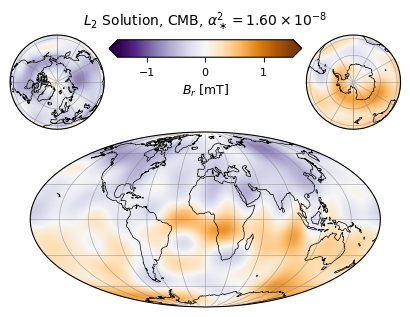

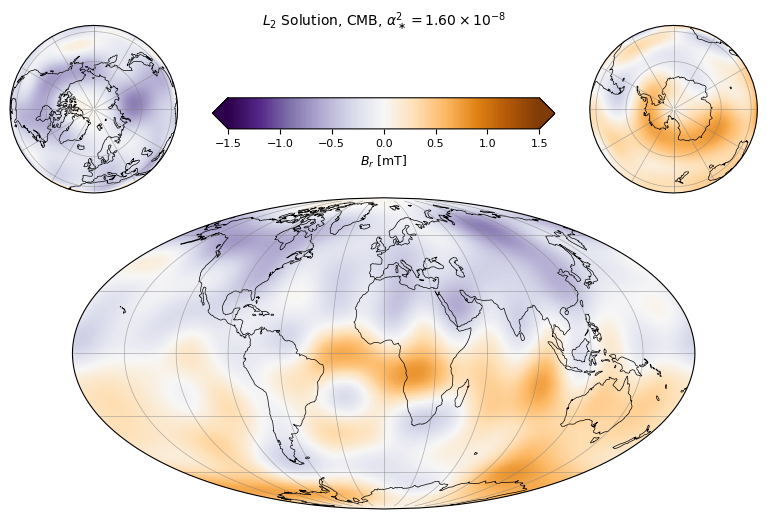

In [36]:
# Best L2 solution
m_best = solve_L2(Gr, H_Br_cmb, d, alpha_corner)
Br_best = Gr_plot @ m_best

title_best = rf"$L_2$ Solution, CMB, $α_\ast^2 = {format_number(alpha_corner**2, sigfigs=3)}$"
fig_best_half = plot_global(
    phi_plot, 90 - theta_plot, Br_best * 1e-6, point_size,
    title=title_best,
    cbar_label="$B_r$ [mT]",
    cmap=plt.cm.PuOr_r,
    limit=limit,
    half_page=True,
)
fig_best_half.savefig(EXPORT_DIR / "sol_L2_cmb.png", **SAVEFIG_ARGS)
plt.show()

fig_best_full = plot_global(
    phi_plot, 90 - theta_plot, Br_best * 1e-6, point_size,
    title=title_best,
    cbar_label="$B_r$ [mT]",
    cmap=plt.cm.PuOr_r,
    limit=limit,
    half_page=False,
)
fig_best_full.savefig(EXPORT_DIR / "sol_L2_cmb_big.png", **SAVEFIG_ARGS)
plt.show()

(field map comparison)

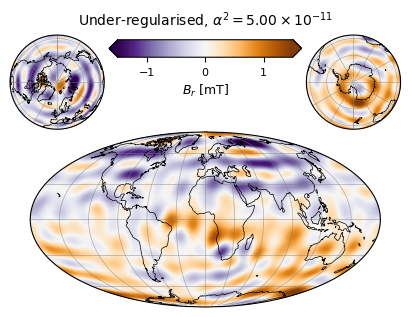

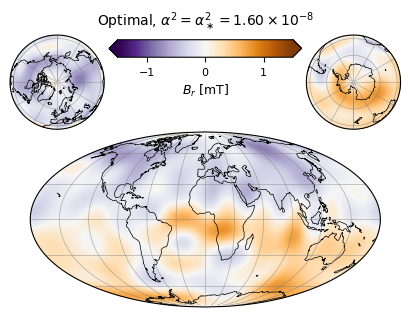

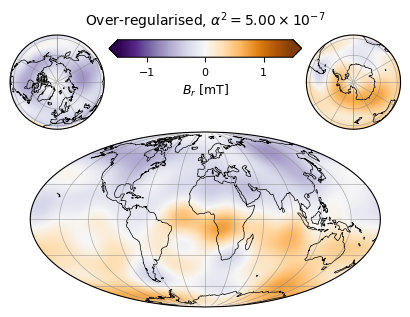

In [ ]:
alpha_compare = [
    np.sqrt(5e-11),        # under-regularised
    alpha_corner,          # optimal
    np.sqrt(5e-7),         # over-regularised
]
labels_compare = ["Under-regularised", "Optimal", "Over-regularised"]

for alpha_i, label_i in zip(alpha_compare, labels_compare):
    m_i = solve_L2(Gr, H_Br_cmb, d, alpha_i)
    Br_i = Gr_plot @ m_i
    optional_middle = r"α_\ast^2=" if np.isclose(alpha_i, alpha_corner) else ""
    title_i = rf"{label_i}, $α^2={optional_middle}{format_number(alpha_i**2, sigfigs=3)}$"
    fig_i = plot_global(
        phi_plot, 90 - theta_plot, Br_i * 1e-6, point_size,
        title=title_i,
        cbar_label="$B_r$ [mT]",
        cmap=plt.cm.PuOr_r,
        limit=limit,
        half_page=True,
    )
    fig_i.savefig(EXPORT_DIR / f"sol_L2_cmb_alpha_{alpha_i**2:.2e}.png", **SAVEFIG_ARGS)
    plt.show()

(optimal power spectra)

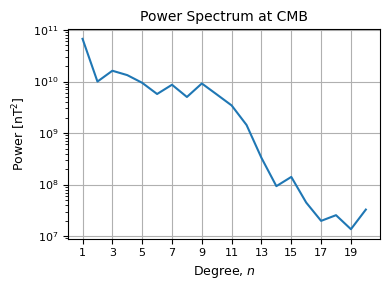

In [ ]:
# Power spectrum
fig_ps = plot_power_spectrum(m_best, N=N, radius=ps_r)
fig_ps.savefig(EXPORT_DIR / "spectrum_L2.png", **SAVEFIG_ARGS)
plt.show()

(different power spectra)

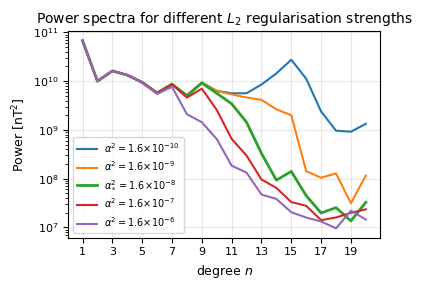

In [54]:
alpha_sq_list = [
    alpha_corner**2 / 100,   # under-regularised
    alpha_corner**2 / 10,
    alpha_corner**2,         # optimal
    alpha_corner**2 * 10,
    alpha_corner**2 * 100,   # over-regularised
]

fig, ax = plt.subplots(figsize=(4, 3))

degrees = np.arange(1, N + 1)

for alpha_sq in alpha_sq_list:
    alpha_now = np.sqrt(alpha_sq)  
    m_now = solve_L2(Gr, H_Br_cmb, d, alpha_now)
    ps_now = cp.model_utils.power_spectrum(m_now, radius=ps_r)

    if np.isclose(alpha_sq, alpha_corner**2):
        label = rf"$\alpha_*^2 = {format_number(alpha_sq, sigfigs=3)}$"
        ax.semilogy(degrees, ps_now, linewidth=2.0, label=label)
    else:
        label = rf"$\alpha^2 = {format_number(alpha_sq, sigfigs=3)}$"
        ax.semilogy(degrees, ps_now, linewidth=1.5, label=label)

ax.set_xlabel("degree $n$", fontsize=9)
ax.set_ylabel(r"Power [nT$^2$]", fontsize=9)
ax.set_title(r"Power spectra for different $L_2$ regularisation strengths", fontsize=10)
ax.set_xticks(np.arange(1, N + 1, 2))
ax.tick_params(labelsize=8)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=7)
fig.tight_layout()

fig.savefig(EXPORT_DIR / "spectrum_L2_comparison.png", **SAVEFIG_ARGS)
plt.show()

(residuals)

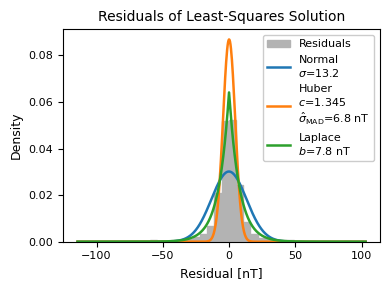

In [ ]:
def huber_location_scale(x, c=1.345, tol=1e-8, max_iter=100):
    """
    Estimate robust Huber location and scale.
    Returns (mu, sigma_huber).
    """
    x = np.asarray(x, dtype=float).ravel()

    mu = np.median(x)
    sigma = stats.median_abs_deviation(x, scale="normal")
    if not np.isfinite(sigma) or sigma <= 0:
        sigma = np.std(x, ddof=1)
    sigma = max(sigma, 1e-12)

    for _ in range(max_iter):
        r = (x - mu) / sigma
        w = np.ones_like(r)
        mask = np.abs(r) > c
        w[mask] = c / np.abs(r[mask])

        mu_new = np.sum(w * x) / np.sum(w)
        sigma_new = np.sqrt(np.mean((w * (x - mu_new)) ** 2))
        sigma_new = max(sigma_new, 1e-12)

        if abs(mu_new - mu) < tol * sigma and abs(sigma_new - sigma) < tol * sigma:
            mu, sigma = mu_new, sigma_new
            break

        mu, sigma = mu_new, sigma_new

    return mu, sigma


# Residuals
residuals = d - Gr @ m_best

mu_norm, sigma_norm = stats.norm.fit(residuals)
mu_huber, sigma_huber = huber_location_scale(residuals, c=1.345)
loc_lap, scale_lap = stats.laplace.fit(residuals)

mad_sigma = stats.median_abs_deviation(residuals, scale="normal")

# Plot range
x = np.linspace(
    min(residuals.min(), -50),
    max(residuals.max(), 50),
    600
)

fig, ax = plt.subplots(figsize=(4, 3))

# Histogram
ax.hist(
    residuals,
    bins=40,
    density=True,
    color="0.7",
    edgecolor="0.7",
    alpha=1.0,
    label="Residuals",
)

# Normal
ax.plot(
    x,
    stats.norm.pdf(x, mu_norm, sigma_norm),
    linewidth=1.8,
    label=f"Normal\n$\\sigma$={sigma_norm:.1f}",
)

# Huber
ax.plot(
    x,
    stats.norm.pdf(x, mu_huber, sigma_huber),
    linewidth=1.8,
    label=f"Huber\n$c$=1.345\n$\\hat{{\\sigma}}_{{\\mathrm{{MAD}}}}$={mad_sigma:.1f} nT",
)

# Laplace
ax.plot(
    x,
    stats.laplace.pdf(x, loc_lap, scale_lap),
    linewidth=1.8,
    label=f"Laplace\n$b$={scale_lap:.1f} nT",
)

ax.set_title("Residuals of Least-Squares Solution", fontsize=10)
ax.set_xlabel("Residual [nT]", fontsize=9)
ax.set_ylabel("Density", fontsize=9)
ax.tick_params(labelsize=8)
ax.legend(fontsize=8, framealpha=1.0)
ax.grid(False)

fig.tight_layout()
fig.savefig(EXPORT_DIR / "residuals_L2_teammate_style.png", **SAVEFIG_ARGS)
plt.show()